In [1]:
# PROJECT DELIVERY PERFORMANCE ANALYSIS

#Consultant Utilization & Client Satisfaction

#Company Name: SmartTech Consulting Pvt. Ltd.
#Department: Business Analytics – Project Management Office (PMO)

#Leadership has asked the PMO to analyze project delivery performance, consultant utilization, and client satisfaction across the consulting practice 

In [2]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
#Load Dataset

df = pd.read_csv("IT_Consulting_Project_Data.csv")

df.head()

,Project_ID,Project_Name,Consulting_Practice,Project_Type,Client_Industry,Client_Name,Project_Manager,Consultant_ID,Consultant_Name,Consultant_Grade,...,Billable_Hours,Project_Budget_USD,Project_Cost_USD,Revenue_USD,Resource_Count,Change_Requests,Risk_Level,Customer_Satisfaction,Client_Rating,Quarter
0,TC0001,AI Digital Transformation Project 1,AI,Digital Transformation,Retail,Reliance Retail,PM_06,C1001,Priya Singh,Manager,...,1748.0,1618090.0,1574572.0,1815629.0,15.0,7.0,Medium,4.4,4.0,Q1
1,TC0002,AI Upgrade Project 2,AI,Upgrade,Insurance,ICICI Lombard,PM_11,C1002,Arjun Nair,Senior Consultant,...,1539.0,1502098.0,1377317.0,1587959.0,16.0,10.0,High,4.3,4.0,Q2
2,TC0003,AI Upgrade Project 3,AI,Upgrade,Banking,ICICI Bank,PM_19,C1003,Amit Verma,Manager,...,1472.0,798599.0,707861.0,782516.0,17.0,11.0,High,3.9,4.0,Q4
3,TC0004,AI Support Project 4,AI,Support,Banking,HDFC Bank,PM_17,C1004,Rahul Sharma,Consultant,...,1232.0,1596428.0,1343526.0,1761313.0,6.0,8.0,High,3.8,4.0,Q3
4,TC0005,Cloud Digital Transformation Project 5,Cloud,Digital Transformation,Retail,Shoppers Stop,PM_15,C1005,Amit Verma,Manager,...,1344.0,1937127.0,1617653.0,1851740.0,8.0,12.0,High,4.2,4.0,Q1


In [4]:
#Check Shape
df.shape

(502, 28)

In [5]:
df.columns

Index(['Project_ID', 'Project_Name', 'Consulting_Practice', 'Project_Type',
       'Client_Industry', 'Client_Name', 'Project_Manager', 'Consultant_ID',
       'Consultant_Name', 'Consultant_Grade', 'Experience_Level',
       'Project_Start_Date', 'Planned_End_Date', 'Actual_End_Date',
       'Project_Duration_Days', 'Completion_Status', 'Delivery_Delay_Days',
       'Utilization_Percentage', 'Billable_Hours', 'Project_Budget_USD',
       'Project_Cost_USD', 'Revenue_USD', 'Resource_Count', 'Change_Requests',
       'Risk_Level', 'Customer_Satisfaction', 'Client_Rating', 'Quarter'],
      dtype='object')

In [6]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Project_ID              501 non-null    object 
 1   Project_Name            501 non-null    object 
 2   Consulting_Practice     501 non-null    object 
 3   Project_Type            501 non-null    object 
 4   Client_Industry         501 non-null    object 
 5   Client_Name             501 non-null    object 
 6   Project_Manager         501 non-null    object 
 7   Consultant_ID           501 non-null    object 
 8   Consultant_Name         501 non-null    object 
 9   Consultant_Grade        501 non-null    object 
 10  Experience_Level        501 non-null    object 
 11  Project_Start_Date      501 non-null    object 
 12  Planned_End_Date        501 non-null    object 
 13  Actual_End_Date         501 non-null    object 
 14  Project_Duration_Days   501 non-null    fl

In [7]:
#Statistical Summary
df.describe()

,Project_Duration_Days,Delivery_Delay_Days,Utilization_Percentage,Billable_Hours,Project_Budget_USD,Project_Cost_USD,Revenue_USD,Resource_Count,Change_Requests,Customer_Satisfaction,Client_Rating
count,501.000000,501.000000,501.000000,501.000000,5.010000e+02,5.010000e+02,5.010000e+02,501.000000,501.000000,501.000000,501.000000
mean,142.051896,6.774451,80.946108,1452.518962,1.403610e+06,1.297384e+06,1.591903e+06,11.690619,5.952096,4.289022,4.183633
std,57.552214,5.079274,10.337461,217.203918,4.632169e+05,4.401627e+05,5.471609e+05,4.765511,3.803380,0.295735,0.402755
min,45.000000,0.000000,55.000000,944.000000,6.016460e+05,5.090390e+05,5.689160e+05,4.000000,0.000000,3.400000,3.000000
25%,92.000000,3.000000,73.000000,1292.000000,9.947400e+05,9.242350e+05,1.134093e+06,8.000000,3.000000,4.100000,4.000000
50%,139.000000,6.000000,82.000000,1458.000000,1.415781e+06,1.316961e+06,1.578092e+06,11.000000,6.000000,4.300000,4.000000
75%,194.000000,10.000000,90.000000,1615.000000,1.779517e+06,1.659129e+06,2.027568e+06,16.000000,9.000000,4.500000,4.000000
max,240.000000,24.000000,100.000000,2000.000000,2.199957e+06,2.258719e+06,2.838894e+06,20.000000,12.000000,5.000000,5.000000


In [8]:
# Missing Values
df.isnull().sum()

Project_ID                1
Project_Name              1
Consulting_Practice       1
Project_Type              1
Client_Industry           1
Client_Name               1
Project_Manager           1
Consultant_ID             1
Consultant_Name           1
Consultant_Grade          1
Experience_Level          1
Project_Start_Date        1
Planned_End_Date          1
Actual_End_Date           1
Project_Duration_Days     1
Completion_Status         1
Delivery_Delay_Days       1
Utilization_Percentage    1
Billable_Hours            1
Project_Budget_USD        1
Project_Cost_USD          1
Revenue_USD               1
Resource_Count            1
Change_Requests           1
Risk_Level                1
Customer_Satisfaction     1
Client_Rating             1
Quarter                   1
dtype: int64

In [9]:
# Handle Missing Values

df.fillna(df.mean(numeric_only=True), inplace=True)

df.fillna("Unknown", inplace=True)

In [10]:
df.isnull().sum()

Project_ID                0
Project_Name              0
Consulting_Practice       0
Project_Type              0
Client_Industry           0
Client_Name               0
Project_Manager           0
Consultant_ID             0
Consultant_Name           0
Consultant_Grade          0
Experience_Level          0
Project_Start_Date        0
Planned_End_Date          0
Actual_End_Date           0
Project_Duration_Days     0
Completion_Status         0
Delivery_Delay_Days       0
Utilization_Percentage    0
Billable_Hours            0
Project_Budget_USD        0
Project_Cost_USD          0
Revenue_USD               0
Resource_Count            0
Change_Requests           0
Risk_Level                0
Customer_Satisfaction     0
Client_Rating             0
Quarter                   0
dtype: int64

In [11]:
# Duplicate Records
df.duplicated().sum()

np.int64(1)

In [12]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
#Exploratory Data Analysis (EDA)

In [15]:
#Project Type Distribution

df['Project_Type'].value_counts()

Project_Type
Migration                 110
Digital Transformation     99
Upgrade                    99
Support                    96
Implementation             96
Unknown                     1
Name: count, dtype: int64

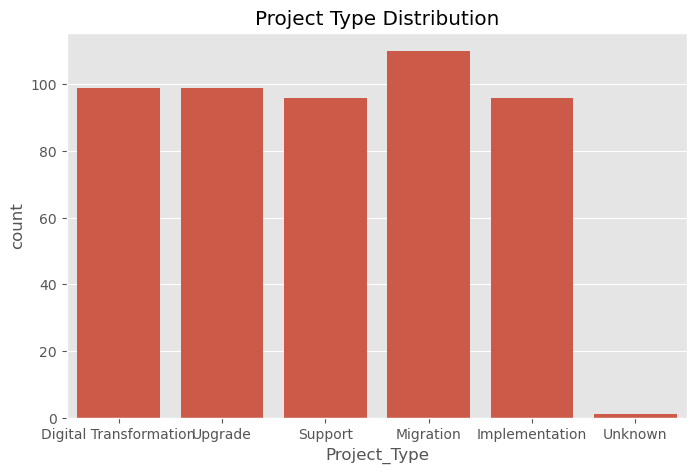

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='Project_Type',data=df)
plt.title("Project Type Distribution")
plt.show()

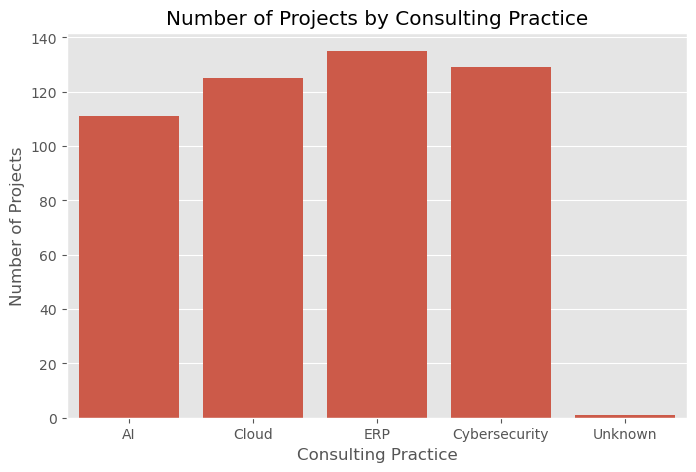

In [17]:
#number of projects by consulting practice

plt.figure(figsize=(8,5))

sns.countplot(x="Consulting_Practice", data=df)

plt.title("Number of Projects by Consulting Practice")
plt.xlabel("Consulting Practice")
plt.ylabel("Number of Projects")

plt.show()

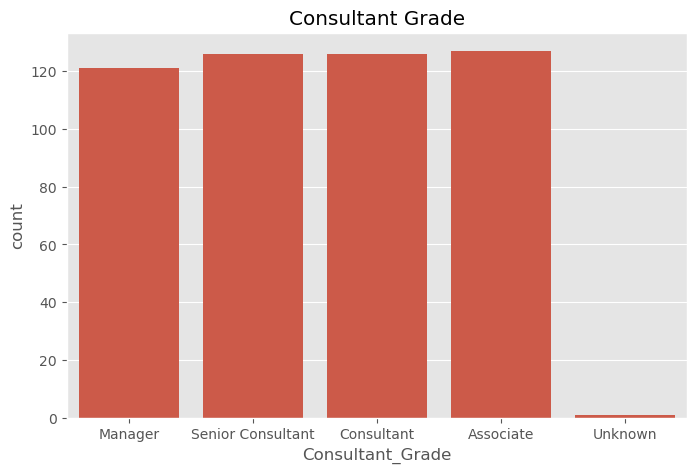

In [18]:
#Consultant Grade

plt.figure(figsize=(8,5))
sns.countplot(x='Consultant_Grade',data=df)
plt.title("Consultant Grade")
plt.show()

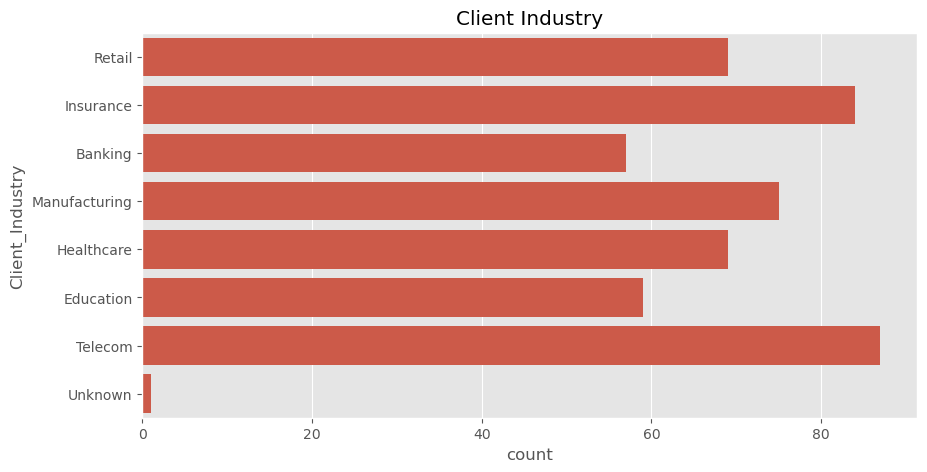

In [19]:
#Client Industry

plt.figure(figsize=(10,5))
sns.countplot(y='Client_Industry',data=df)
plt.title("Client Industry")
plt.show()

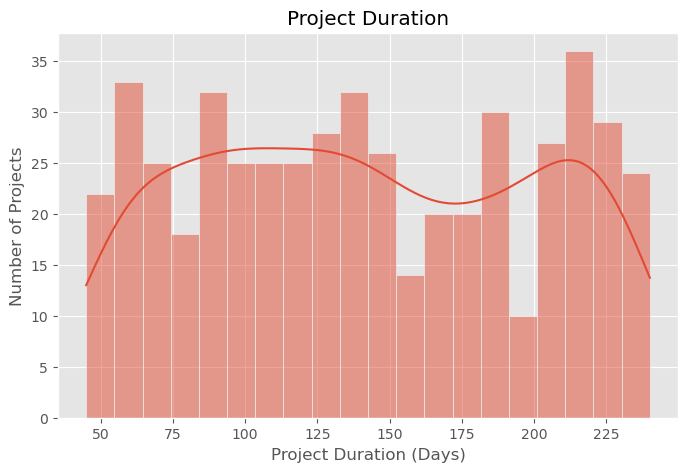

In [20]:
#Project Duration

plt.figure(figsize=(8,5))

sns.histplot(df['Project_Duration_Days'], bins=20, kde=True)

plt.title("Project Duration")
plt.xlabel("Project Duration (Days)")
plt.ylabel("Number of Projects")

plt.show()

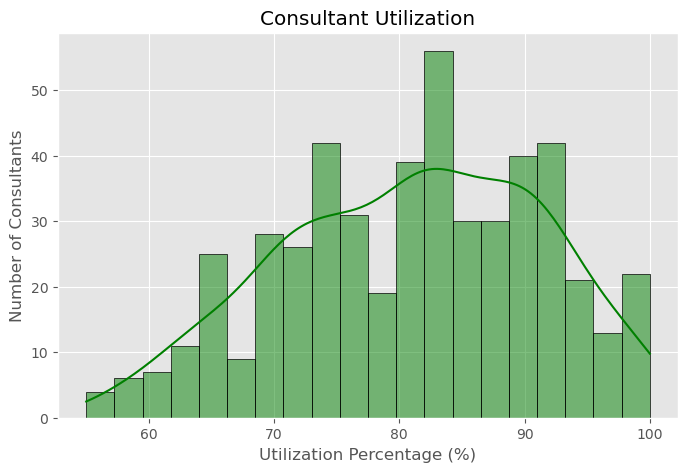

In [21]:
#Consultant Utilization

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Utilization_Percentage',
    bins=20,
    kde=True,
    color='green',
    edgecolor='black'
)

plt.title("Consultant Utilization")
plt.xlabel("Utilization Percentage (%)")
plt.ylabel("Number of Consultants")

plt.show()

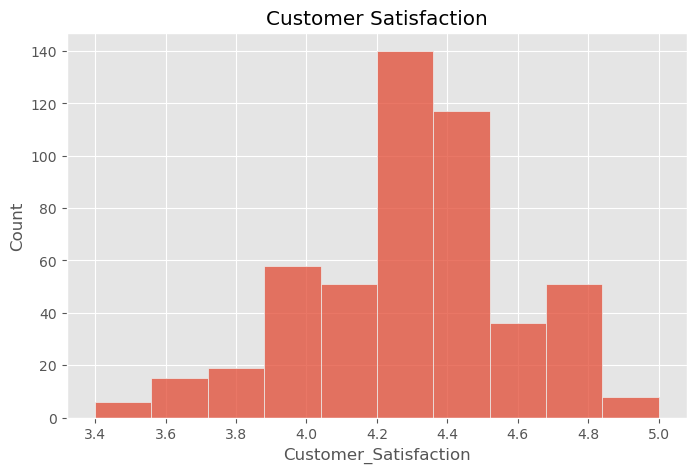

In [22]:
#Customer Satisfaction

plt.figure(figsize=(8,5))
sns.histplot(df['Customer_Satisfaction'],bins=10)
plt.title("Customer Satisfaction")
plt.show()

In [23]:
#Project Delivery Performance

In [24]:
#Group Projects by Consulting Practice

practice=df.groupby('Consulting_Practice').agg(

Projects=('Project_ID','count'),

Completion_Rate=('Completion_Status',
lambda x:(x=="Completed").mean()*100),

Average_Delivery_Delay=('Delivery_Delay_Days','mean')

)

print(practice)

                     Projects  Completion_Rate  Average_Delivery_Delay
Consulting_Practice                                                   
AI                        111        93.693694                5.684685
Cloud                     125        85.600000                4.768000
Cybersecurity             129        91.472868                4.883721
ERP                       135        71.851852               11.385185
Unknown                     1         0.000000                6.774451


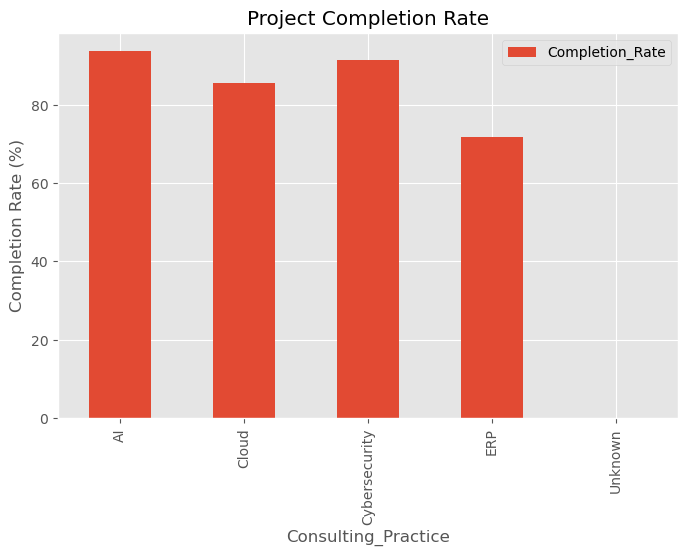

In [25]:
#Bar Chart

practice[['Completion_Rate']].plot(kind='bar',figsize=(8,5))
plt.title("Project Completion Rate")
plt.ylabel("Completion Rate (%)")
plt.show()

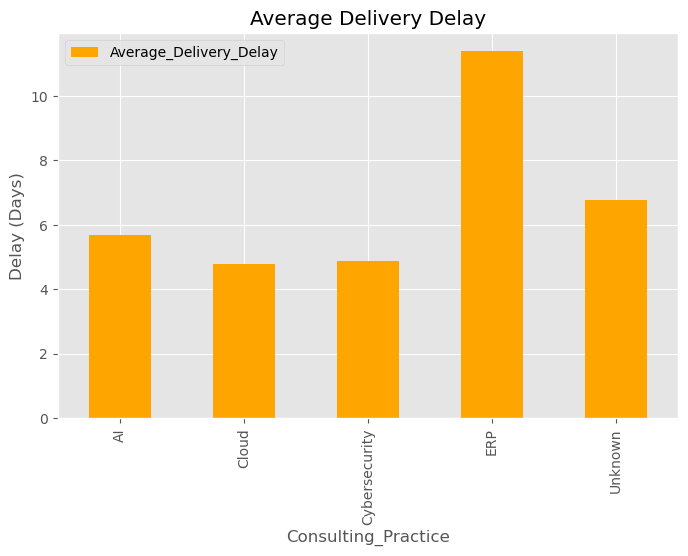

In [26]:
#Average Delay

practice[['Average_Delivery_Delay']].plot(kind='bar',color='orange',figsize=(8,5))
plt.title("Average Delivery Delay")
plt.ylabel("Delay (Days)")
plt.show()

In [27]:
# CONSULTANT UTILIZATION ANALYSIS

In [28]:
# Average Utilization

util=df.groupby('Experience_Level')['Utilization_Percentage'].mean()

print(util)

Experience_Level
0-2 Years     68.149606
10+ Years     92.049587
3-5 Years     78.000000
6-10 Years    86.039683
Unknown       80.946108
Name: Utilization_Percentage, dtype: float64


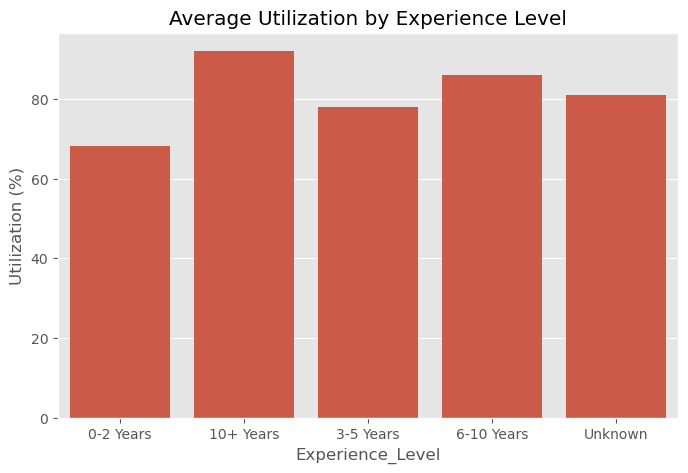

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x=util.index,y=util.values)
plt.title("Average Utilization by Experience Level")
plt.ylabel("Utilization (%)")
plt.show()

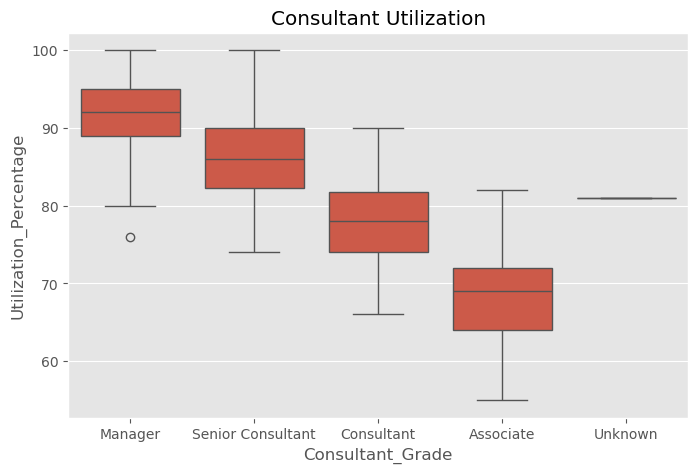

In [30]:
# Box Plot

plt.figure(figsize=(8,5))
sns.boxplot(x='Consultant_Grade',
y='Utilization_Percentage',
data=df)

plt.title("Consultant Utilization")
plt.show()

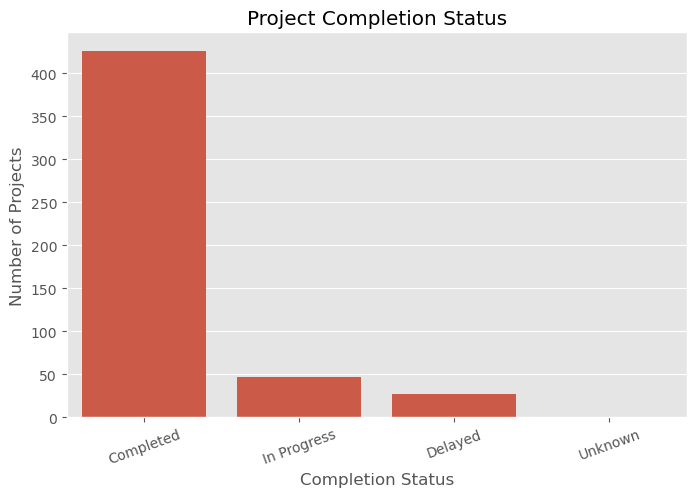

In [49]:
# Project Completion Status

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Completion_Status"
)

plt.title("Project Completion Status")
plt.xlabel("Completion Status")
plt.ylabel("Number of Projects")

plt.xticks(rotation=20)

plt.show()

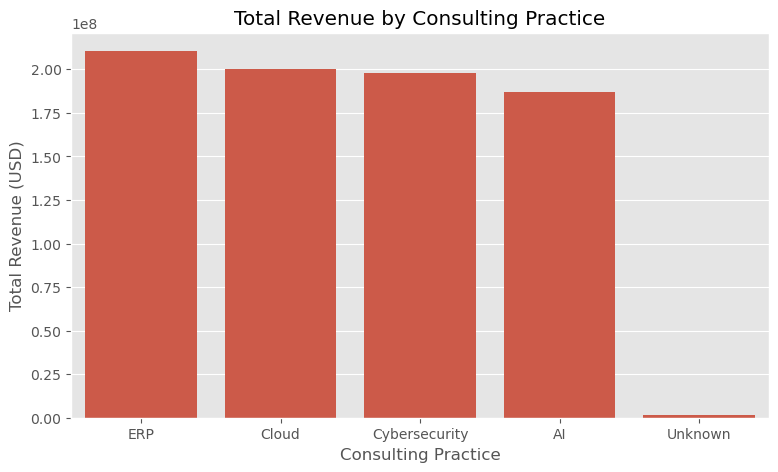

In [50]:
# Revenue by Consulting Practice

revenue_practice = df.groupby(
    "Consulting_Practice"
)["Revenue_USD"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,5))

sns.barplot(
    x=revenue_practice.index,
    y=revenue_practice.values
)

plt.title("Total Revenue by Consulting Practice")
plt.xlabel("Consulting Practice")
plt.ylabel("Total Revenue (USD)")

plt.show()

In [32]:
#Over-utilized Consultants (Utilization > 90%)

over_utilized = df[df["Utilization_Percentage"] > 90][[
    "Project_ID",
    "Project_Name",
    "Project_Type",
    "Consulting_Practice",
    "Client_Industry",
    "Client_Name",
    "Consultant_Name",
    "Consultant_Grade",
    "Experience_Level",
    "Project_Duration_Days",
    "Delivery_Delay_Days",
    "Utilization_Percentage",
    "Customer_Satisfaction",
    "Completion_Status",
    "Revenue_USD",
    "Quarter"
]]

over_utilized

,Project_ID,Project_Name,Project_Type,Consulting_Practice,Client_Industry,Client_Name,Consultant_Name,Consultant_Grade,Experience_Level,Project_Duration_Days,Delivery_Delay_Days,Utilization_Percentage,Customer_Satisfaction,Completion_Status,Revenue_USD,Quarter
0,TC0001,AI Digital Transformation Project 1,Digital Transformation,AI,Retail,Reliance Retail,Priya Singh,Manager,10+ Years,214.0,0.0,92.0,4.4,Completed,1815629.0,Q1
2,TC0003,AI Upgrade Project 3,Upgrade,AI,Banking,ICICI Bank,Amit Verma,Manager,10+ Years,152.0,10.0,92.0,3.9,Completed,782516.0,Q4
16,TC0017,AI Implementation Project 17,Implementation,AI,Retail,Reliance Retail,Ananya Rao,Manager,10+ Years,143.0,6.0,92.0,4.6,In Progress,953490.0,Q1
17,TC0018,AI Digital Transformation Project 18,Digital Transformation,AI,Retail,Reliance Retail,Ananya Rao,Manager,10+ Years,239.0,8.0,98.0,4.2,Completed,1290973.0,Q1
31,TC0032,AI Digital Transformation Project 32,Digital Transformation,AI,Telecom,Vodafone Idea,Priya Singh,Senior Consultant,6-10 Years,236.0,0.0,94.0,4.8,Completed,1020605.0,Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,TC0449,AI Upgrade Project 449,Upgrade,AI,Manufacturing,Tata Motors,Priya Singh,Manager,10+ Years,191.0,0.0,100.0,4.8,Completed,1346054.0,Q1
468,TC0469,Cloud Digital Transformation Project 469,Digital Transformation,Cloud,Education,upGrad,Karan Joshi,Senior Consultant,6-10 Years,161.0,5.0,96.0,4.4,Completed,588014.0,Q3
474,TC0475,Cloud Migration Project 475,Migration,Cloud,Healthcare,Apollo Hospitals,Sneha Patel,Manager,10+ Years,204.0,12.0,96.0,3.9,Completed,785716.0,Q4
489,TC0490,AI Upgrade Project 490,Upgrade,AI,Healthcare,Apollo Hospitals,Vikas Mehta,Senior Consultant,6-10 Years,215.0,7.0,94.0,4.2,Completed,1095096.0,Q2


In [33]:
# Under Utilized Consultants (<60%)

under_utilized = df[df["Utilization_Percentage"] < 60][[
    "Project_ID",
    "Project_Name",
    "Project_Type",
    "Consulting_Practice",
    "Client_Industry",
    "Client_Name",
    "Consultant_Name",
    "Consultant_Grade",
    "Experience_Level",
    "Project_Duration_Days",
    "Delivery_Delay_Days",
    "Utilization_Percentage",
    "Customer_Satisfaction",
    "Completion_Status",
    "Revenue_USD",
    "Quarter"
]]

under_utilized


,Project_ID,Project_Name,Project_Type,Consulting_Practice,Client_Industry,Client_Name,Consultant_Name,Consultant_Grade,Experience_Level,Project_Duration_Days,Delivery_Delay_Days,Utilization_Percentage,Customer_Satisfaction,Completion_Status,Revenue_USD,Quarter
9,TC0010,Cybersecurity Upgrade Project 10,Upgrade,Cybersecurity,Education,Simplilearn,Karan Joshi,Associate,0-2 Years,186.0,1.0,56.0,4.7,Completed,2178851.0,Q2
47,TC0048,Cloud Migration Project 48,Migration,Cloud,Telecom,Airtel,Karan Joshi,Associate,0-2 Years,82.0,11.0,56.0,4.2,Completed,1864622.0,Q3
66,TC0067,ERP Implementation Project 67,Implementation,ERP,Manufacturing,L&T,Sneha Patel,Associate,0-2 Years,116.0,8.0,58.0,4.4,Completed,1156600.0,Q3
176,TC0177,Cybersecurity Upgrade Project 177,Upgrade,Cybersecurity,Manufacturing,L&T,Sneha Patel,Associate,0-2 Years,68.0,10.0,58.0,4.4,Completed,1900703.0,Q4
257,TC0258,Cybersecurity Migration Project 258,Migration,Cybersecurity,Education,upGrad,Arjun Nair,Associate,0-2 Years,65.0,0.0,55.0,4.6,Completed,1141317.0,Q1
277,TC0278,AI Migration Project 278,Migration,AI,Education,upGrad,Sneha Patel,Associate,0-2 Years,221.0,3.0,57.0,4.3,Completed,2147497.0,Q1
358,TC0359,AI Digital Transformation Project 359,Digital Transformation,AI,Retail,Shoppers Stop,Neha Kapoor,Associate,0-2 Years,92.0,12.0,59.0,3.8,Completed,2270618.0,Q4
359,TC0360,Cybersecurity Implementation Project 360,Implementation,Cybersecurity,Insurance,HDFC Life,Karan Joshi,Associate,0-2 Years,236.0,9.0,59.0,4.1,In Progress,2255519.0,Q4
404,TC0405,AI Migration Project 405,Migration,AI,Insurance,LIC,Neha Kapoor,Associate,0-2 Years,140.0,7.0,59.0,4.2,Completed,2371078.0,Q2
407,TC0408,AI Implementation Project 408,Implementation,AI,Insurance,HDFC Life,Ananya Rao,Associate,0-2 Years,102.0,4.0,59.0,4.5,Completed,2081806.0,Q1


In [34]:
# CLIENT SATISFACTION ANALYSIS

In [35]:
#Average Rating

satisfaction=df.groupby('Project_Type')['Customer_Satisfaction'].mean()

print(satisfaction)

Project_Type
Digital Transformation    4.318182
Implementation            4.247917
Migration                 4.284545
Support                   4.309375
Unknown                   4.289022
Upgrade                   4.283838
Name: Customer_Satisfaction, dtype: float64


In [36]:
#Client Satisfaction Analysis

average_satisfaction = df.groupby("Consulting_Practice")["Customer_Satisfaction"].mean().sort_values(ascending=False)

print(average_satisfaction)

Consulting_Practice
Cybersecurity    4.379845
Cloud            4.377600
AI               4.330631
Unknown          4.289022
ERP              4.085185
Name: Customer_Satisfaction, dtype: float64


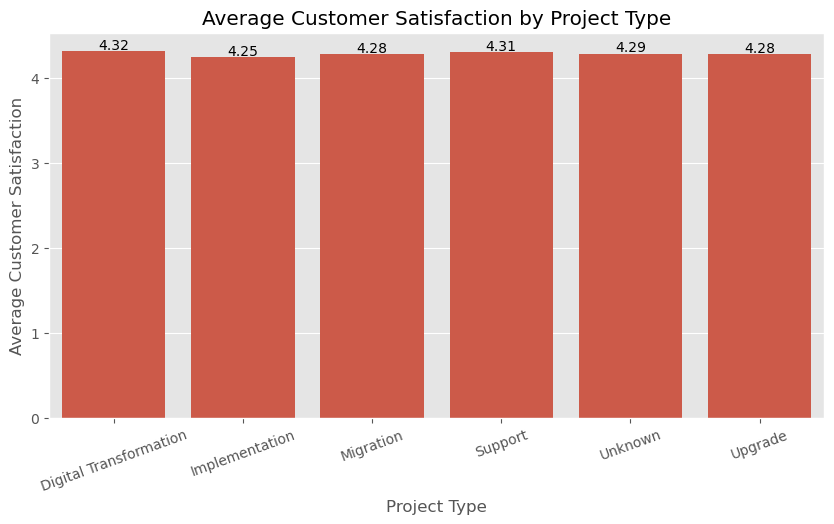

In [37]:
average_satisfaction = df.groupby("Project_Type")["Customer_Satisfaction"].mean()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=average_satisfaction.index,
    y=average_satisfaction.values
)

plt.title("Average Customer Satisfaction by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Average Customer Satisfaction")

plt.xticks(rotation=20)

for i, value in enumerate(average_satisfaction.values):
    ax.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

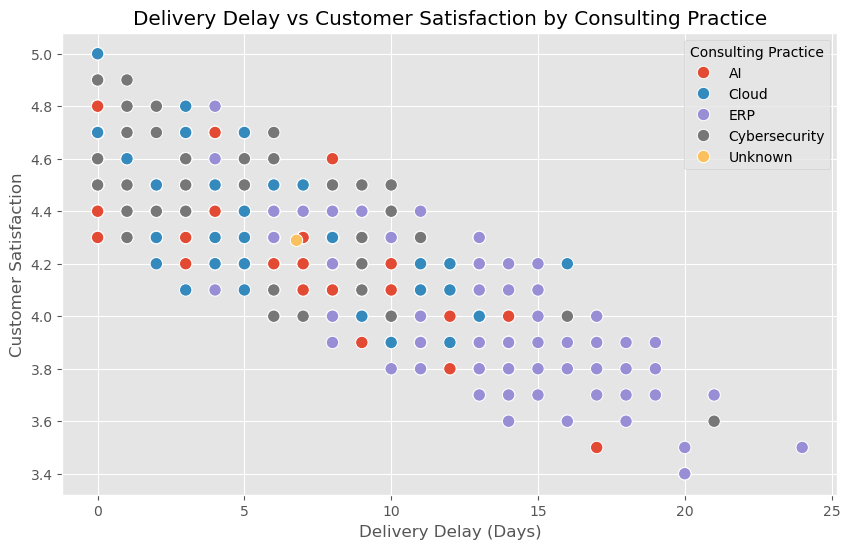

In [38]:
# Relationship Between Delivery Delay, Customer Satisfaction
# and Consulting Practice

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Delivery_Delay_Days",
    y="Customer_Satisfaction",
    hue="Consulting_Practice",
    s=80
)

plt.title("Delivery Delay vs Customer Satisfaction by Consulting Practice")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Customer Satisfaction")
plt.legend(title="Consulting Practice")

plt.show()

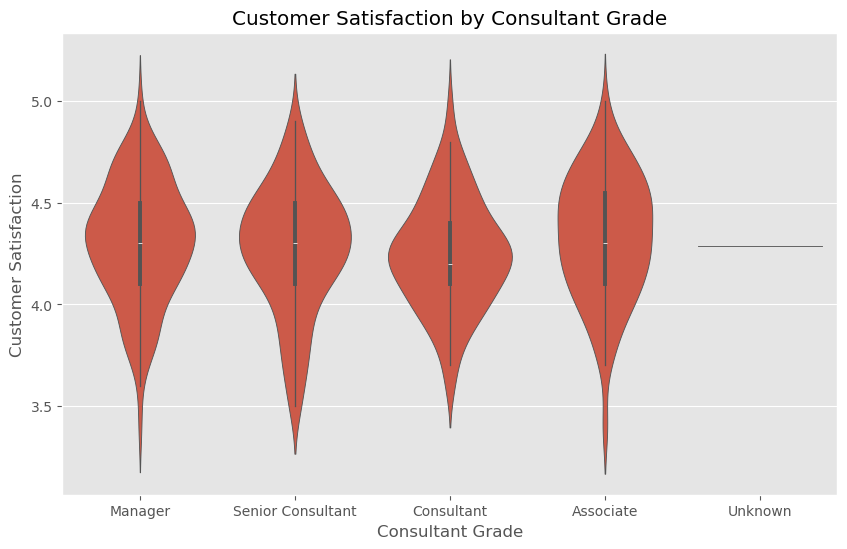

In [39]:
# Violin Plot: Customer Satisfaction by Consultant Grade

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Consultant_Grade",
    y="Customer_Satisfaction"
)

plt.title("Customer Satisfaction by Consultant Grade")
plt.xlabel("Consultant Grade")
plt.ylabel("Customer Satisfaction")

plt.show()

In [40]:
# Correlation

corr=df[['Delivery_Delay_Days',
'Client_Rating']].corr()

print(corr)

                     Delivery_Delay_Days  Client_Rating
Delivery_Delay_Days             1.000000      -0.516741
Client_Rating                  -0.516741       1.000000


In [41]:
# QUARTERLY PERFORMANCE TREND

In [42]:
#Revenue

quarter=df.groupby('Quarter').agg(

Revenue=('Revenue_USD','sum'),

Average_Utilization=('Utilization_Percentage','mean')

)

print(quarter)


              Revenue  Average_Utilization
Quarter                                   
Q1       1.944389e+08            82.089431
Q2       1.918651e+08            80.319328
Q3       2.094590e+08            80.410448
Q4       1.999647e+08            80.903226
Unknown  1.591903e+06            80.946108


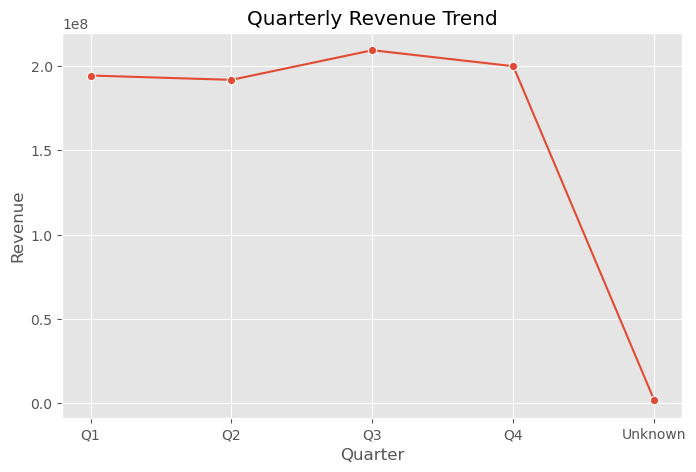

In [43]:
# Revenue Trend

plt.figure(figsize=(8,5))

sns.lineplot(

x=quarter.index,

y=quarter['Revenue'],

marker='o'

)

plt.title("Quarterly Revenue Trend")

plt.show()

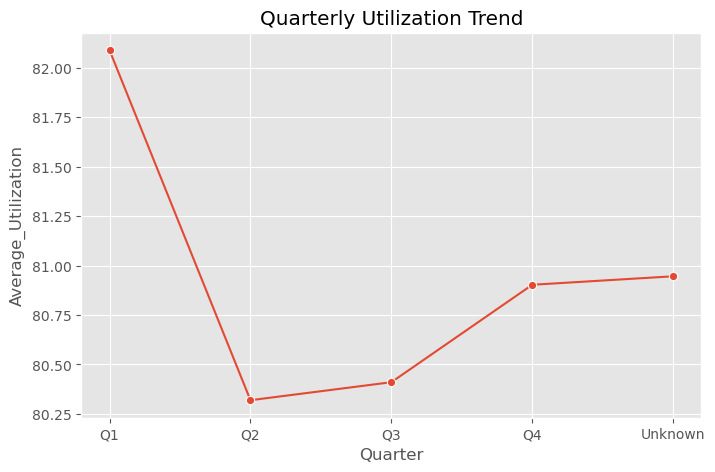

In [44]:
# Utilization Trend

plt.figure(figsize=(8,5))

sns.lineplot(

x=quarter.index,

y=quarter['Average_Utilization'],

marker='o'

)

plt.title("Quarterly Utilization Trend")

plt.show()

<Figure size 1200x800 with 0 Axes>

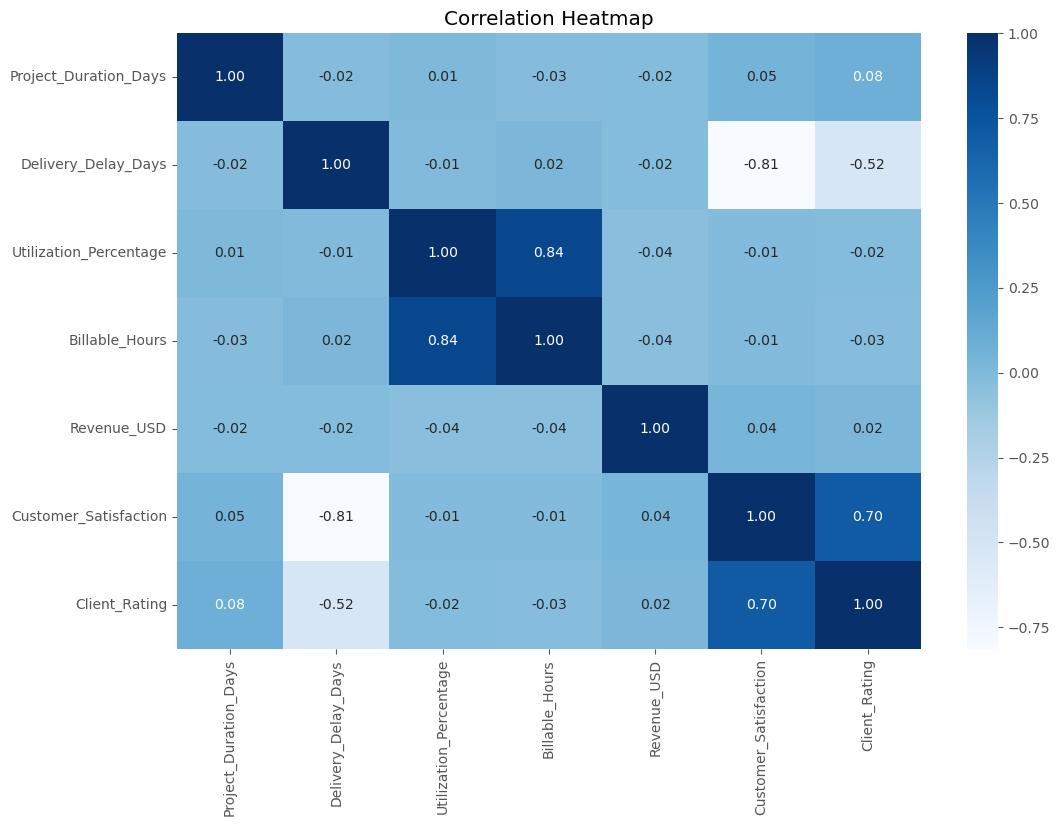

In [45]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

plt.figure(figsize=(12,8))

corr = df[[
    "Project_Duration_Days",
    "Delivery_Delay_Days",
    "Utilization_Percentage",
    "Billable_Hours",
    "Revenue_USD",
    "Customer_Satisfaction",
    "Client_Rating"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [46]:
# Business Recommendations

In [47]:
# 1. Reduce Project Delivery Delays
# 2. Balance Consultant Workload
# 3. Increase Resource Utilization
# 4. Improve Client Satisfaction
# 5. Focus on Low-Performing Consulting Practices
# 6. Improve Revenue Growth
# 7. Enhance Project Quality
# 8. Monitor Key Performance Indicators (KPIs)